Course: Introduction to Machine Learning
Project Title: Target Group Identification on X (Twitter)
Topic: Statistical Analysis and Classification of Israeli Users

Submitted by:
Matan Moridan 213445471
Ofir Ovadia 32415098


## Installing Required Libraries
Installing all the libraries required for the project: pandas, matplotlib, seaborn, scikit-learn, xgboost and openpyxl.


In [2]:
!pip install -q pandas matplotlib seaborn scikit-learn xgboost openpyxl


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports and Data Loading
Importing the libraries and loading the dataset (Excel file) from the 'Data' directory into a pandas DataFrame.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import cohen_kappa_score

file_path = 'Data/final_israeli_users.xlsx'
df = pd.read_excel(file_path) 
df

,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage
0,amit_segal,False,22500,46.0,834700.0,פרשן פוליטי | חדשות 12 וידיעות אחרונות | אבא ש...,jerusalem israel,joined february 2010,Israeli,1
1,DudyBornovski,False,828,337.0,10300.0,who’s your daddy,tel-aviv israel,joined may 2010,Israeli,2
2,RamiRamii20,False,0,11.0,161.0,שאל תדע,nazareth,joined january 2022,Israeli,1
3,irish4israel,True,24800,NaN,NaN,this acc is now closed . follow ireland’s new ...,ireland,joined december 2010,Israeli,3
4,FleurEast,False,22500,4727.0,222100.0,singing dancing and laughing my way through li...,NaN,joined september 2010,Israeli,3
...,...,...,...,...,...,...,...,...,...,...
6960,itaylanda12,False,1126,881.0,123.0,NaN,israel,joined april 2023,Israeli,2
6961,DanShadur,False,66,356.0,158.0,documentary filmmaker producer and podcast host,israel,joined november 2018,Israeli,2
6962,SorinaMatei,False,6437,5961.0,5976.0,anchor news reporter blogger - investigative j...,bucharest romania,joined march 2009,Israeli,3
6963,TonyAbuAJ,False,5590,2290.0,423.0,לְעֵת תָּכִין מַטְבֵּחַ מִצָּר הַמְנַבֵּחַ,NaN,joined august 2019,Israeli,1


## Helper Functions for Safe Saving
Helper functions for safely saving CSV files and plots without overwriting existing files (unless overwrite=True is provided).


In [4]:
# Helper functions for safe file saving

def save_csv_safely(df_to_save, output_path, overwrite=False):
    """
    Save a DataFrame to a CSV file only if the file does not already exist,
    unless overwrite=True is provided.
    """
    
    if overwrite or not os.path.exists(output_path):
        df_to_save.to_csv(output_path, index=False, encoding="utf-8-sig")
        print(f"Saved: {output_path}")
    else:
        print(f"File already exists. No changes were made: {output_path}")


def save_plot_safely(output_path, overwrite=False):
    """
    Save the current matplotlib figure only if the file does not already exist,
    unless overwrite=True is provided.
    """
    
    if overwrite or not os.path.exists(output_path):
        plt.savefig(output_path, bbox_inches="tight")
        print(f"Saved: {output_path}")
    else:
        print(f"File already exists. No changes were made: {output_path}")

## Data Preprocessing
Cleaning the 'join_date' string and converting it into a standard datetime object.


In [5]:


df['join_date_parsed'] = df['join_date'].str.replace('joined ', '')
df['join_date_parsed'] = pd.to_datetime(df['join_date_parsed'], format='%B %Y', errors='coerce')

# Display the cleaned dates to ensure successful conversion
df[['join_date', 'join_date_parsed']]

,join_date,join_date_parsed
0,joined february 2010,2010-02-01
1,joined may 2010,2010-05-01
2,joined january 2022,2022-01-01
3,joined december 2010,2010-12-01
4,joined september 2010,2010-09-01
...,...,...
6960,joined april 2023,2023-04-01
6961,joined november 2018,2018-11-01
6962,joined march 2009,2009-03-01
6963,joined august 2019,2019-08-01


## Statistical Metrics & Export
Calculating min, max, mean, median, and standard deviation for the key metrics, and saving the results to 'author_statistics.csv'.


In [6]:
total_users = df['username'].nunique()

stats_data = {
    'Metric': [
        'Total unique users',
        'Min posts', 'Max posts', 'Average posts', 'Median posts', 'Std posts',
        'Min followers', 'Max followers', 'Average followers', 'Median followers', 'Std followers',
        'Min following', 'Max following', 'Average following', 'Median following', 'Std following',
        'Oldest join date', 'Newest join date'
    ],
    'Value': [
        total_users,
        df['posts'].min(), df['posts'].max(), round(df['posts'].mean(), 2), df['posts'].median(), round(df['posts'].std(), 2),
        df['followers'].min(), df['followers'].max(), round(df['followers'].mean(), 2), df['followers'].median(), round(df['followers'].std(), 2),
        df['following'].min(), df['following'].max(), round(df['following'].mean(), 2), df['following'].median(), round(df['following'].std(), 2),
        df['join_date_parsed'].min().strftime('%Y-%m'), df['join_date_parsed'].max().strftime('%Y-%m')
    ]
}

stats_df = pd.DataFrame(stats_data)

# Export the statistics to a CSV file
save_csv_safely(stats_df, "author_statistics.csv", overwrite=False)

# Display the summary table
stats_df

File already exists. No changes were made: author_statistics.csv


,Metric,Value
0,Total unique users,6965
1,Min posts,0
2,Max posts,1300000
3,Average posts,20947.22
4,Median posts,5347.0
5,Std posts,51592.24
6,Min followers,0.0
7,Max followers,65500000.0
8,Average followers,116158.16
9,Median followers,2839.0


## Visualization
Creating and saving histograms for followers, following, and posts, on a logarithmic scale.


File already exists. No changes were made: followers_histogram.png


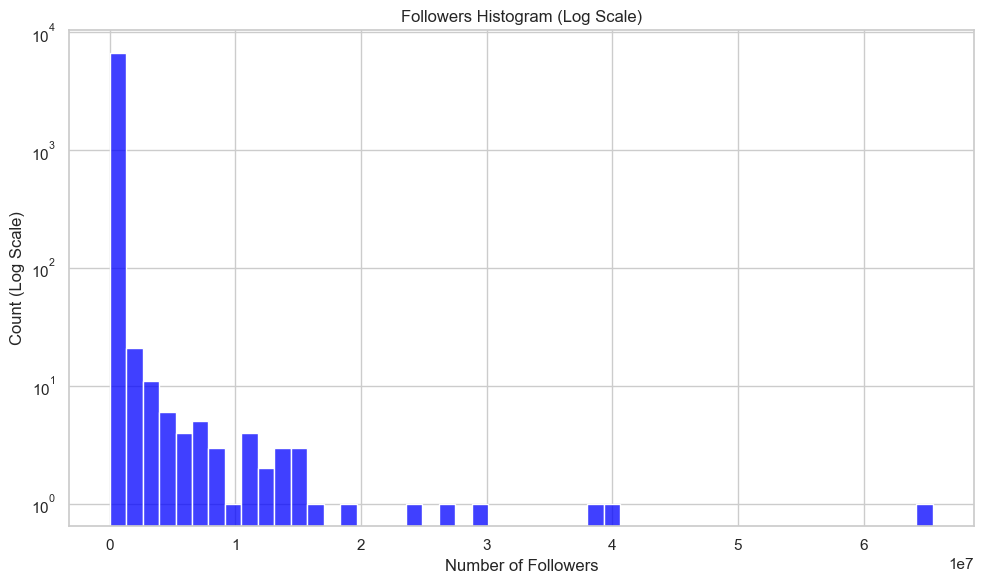

File already exists. No changes were made: following_histogram.png


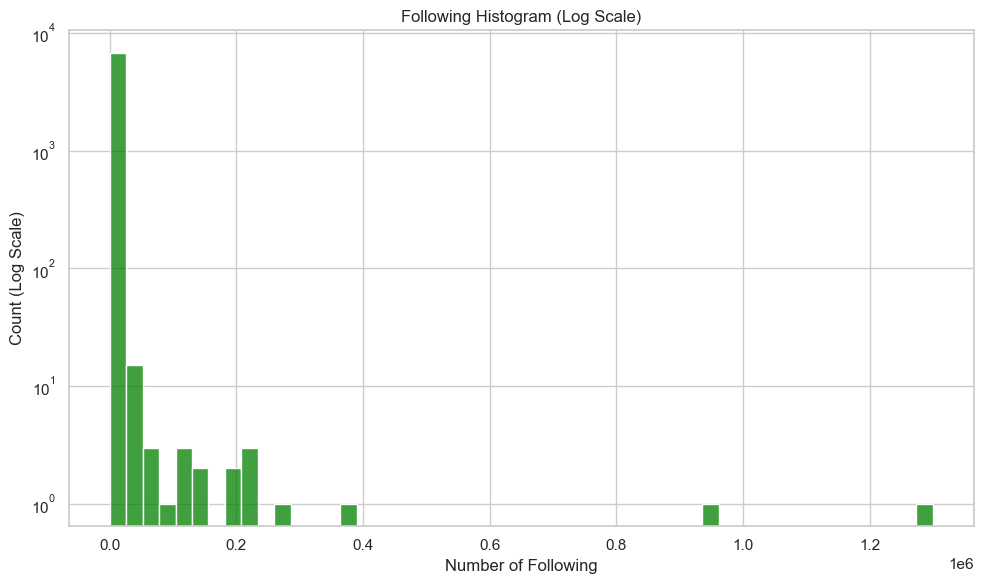

File already exists. No changes were made: posts_histogram.png


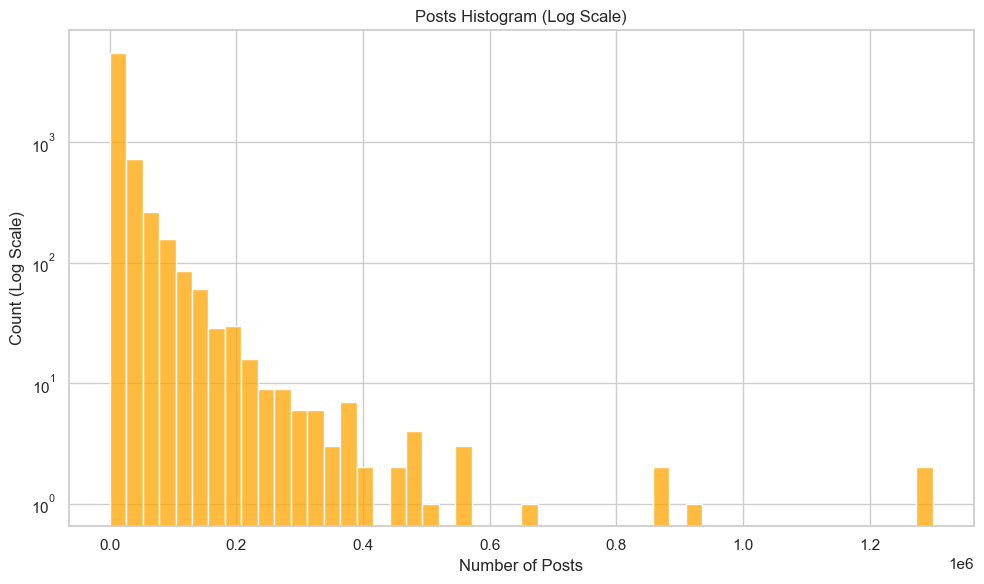

In [7]:
sns.set_theme(style="whitegrid")
# 1. Followers Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['followers'], bins=50, color='blue')
plt.yscale('log')
plt.title('Followers Histogram (Log Scale)')
plt.xlabel('Number of Followers')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
save_plot_safely("followers_histogram.png", overwrite=False)
plt.show()

# 2. Following Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['following'], bins=50, color='green')
plt.yscale('log')
plt.title('Following Histogram (Log Scale)')
plt.xlabel('Number of Following')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
save_plot_safely("following_histogram.png", overwrite=False)
plt.show()

# 3. Posts Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['posts'], bins=50, color='orange')
plt.yscale('log')
plt.title('Posts Histogram (Log Scale)')
plt.xlabel('Number of Posts')
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
save_plot_safely("posts_histogram.png", overwrite=False)
plt.show()

## Random Sampling for Manual Annotation
Selecting a random subset of 100 users from the dataset in order to create the initial manually labeled dataset.


In [8]:
# Randomly select 100 users from the dataset
sample_df = df.sample(n=100, random_state=42)

# Display the first rows of the sampled dataset
sample_df

,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage,join_date_parsed
1335,Roy_Iddan,False,118400,5619.0,79100.0,tv writer uke player + high functioning sociop...,israel,joined may 2009,Israeli,1,2009-05-01
5679,RayneNGrace,False,652500,5459.0,3827.0,imperfect loved by a perfect god! \nmarried to...,blessed usa,joined april 2011,Israeli,3,2011-04-01
5962,shirellaloom,False,23000,680.0,10300.0,כתבת יו''ש | עכשיו 14 | אמא לשני קטנים מתוקים ...,ישראל,joined february 2016,Israeli,1,2016-02-01
37,raananshaked,False,6425,717.0,53300.0,כעס. למרות כל מה שג'וי אומרת כדי לנסות להרגיע ...,NaN,joined march 2009,Israeli,1,2009-03-01
5939,IsraelMOH,False,3506,112.0,20800.0,הטוויטר הרשמי של משרד הבריאות | הצטרפו לערוץ ה...,israel,joined december 2013,Israeli,1,2013-12-01
...,...,...,...,...,...,...,...,...,...,...,...
4258,Lauren_Provost,False,14000,2932.0,10500.0,journalisme numérique dans un quotidien libre....,paris,joined march 2010,Israeli,3,2010-03-01
1600,Yesh_Din,False,845,279.0,12200.0,yesh din is an israeli human rights ngo workin...,west bank/tel aviv,joined september 2022,Israeli,2,2022-09-01
4728,ElfeVan,False,19200,663.0,273.0,NaN,niederlande,joined july 2020,Israeli,2,2020-07-01
742,asafzamir,False,1544,481.0,35800.0,וממלא מקומו,NaN,joined march 2009,Israeli,1,2009-03-01


## Annotation Dataset Preparation
Preparing the sampled dataset for manual annotation by selecting the relevant columns and creating empty annotation fields.


In [9]:
# Keep only relevant columns for annotation
annotation_df = sample_df[['username', 'bio', 'location']].copy()

# Create empty annotation columns
annotation_df['target_population'] = ""
annotation_df['locals_vs_diaspora'] = ""
annotation_df['person_vs_organization'] = ""
annotation_df['comments'] = ""

# Display the annotation dataset
annotation_df

,username,bio,location,target_population,locals_vs_diaspora,person_vs_organization,comments
1335,Roy_Iddan,tv writer uke player + high functioning sociop...,israel,,,,
5679,RayneNGrace,imperfect loved by a perfect god! \nmarried to...,blessed usa,,,,
5962,shirellaloom,כתבת יו''ש | עכשיו 14 | אמא לשני קטנים מתוקים ...,ישראל,,,,
37,raananshaked,כעס. למרות כל מה שג'וי אומרת כדי לנסות להרגיע ...,NaN,,,,
5939,IsraelMOH,הטוויטר הרשמי של משרד הבריאות | הצטרפו לערוץ ה...,israel,,,,
...,...,...,...,...,...,...,...
4258,Lauren_Provost,journalisme numérique dans un quotidien libre....,paris,,,,
1600,Yesh_Din,yesh din is an israeli human rights ngo workin...,west bank/tel aviv,,,,
4728,ElfeVan,NaN,niederlande,,,,
742,asafzamir,וממלא מקומו,NaN,,,,


## Saving Annotation Files
Saving the annotation dataset into two separate files (one per annotator), skipping files that already exist.


In [10]:

ofir_path = "Classification/iteration_1/iteration_1_annotation_ofir.csv"
if not os.path.exists(ofir_path):
    annotation_df.to_csv(ofir_path, index=False, encoding='utf-8-sig')
    print(f"Created: {ofir_path}")
else:
    print(f"File already exists, skipped: {ofir_path}")

matan_path = "Classification/iteration_1/iteration_1_annotation_matan.csv"
if not os.path.exists(matan_path):
    annotation_df.to_csv(matan_path, index=False, encoding='utf-8-sig')
    print(f"Created: {matan_path}")
else:
    print(f"File already exists, skipped: {matan_path}")

File already exists, skipped: Classification/iteration_1/iteration_1_annotation_ofir.csv
File already exists, skipped: Classification/iteration_1/iteration_1_annotation_matan.csv


## Inter-Rater Agreement & Conflict Extraction
Merging the independent annotations of both team members and extracting the rows where they disagreed; the conflicting records are exported to a dedicated file for joint review.


In [11]:
df_matan = pd.read_csv('Classification/iteration_1/iteration_1_annotation_matan.csv')
df_ofir = pd.read_csv('Classification/iteration_1/iteration_1_annotation_ofir.csv')

# Merge the dataframes based on the username column
df_merged = pd.merge(df_matan, df_ofir, on='username', suffixes=('_matan', '_ofir'))

# Define the columns that need to be compared
label_columns = ['target_population', 'locals_vs_diaspora', 'person_vs_organization']

# Create a condition (mask) to find rows where at least one label does not match
conflict_mask = (
    (df_merged['target_population_matan'] != df_merged['target_population_ofir']) |
    (df_merged['locals_vs_diaspora_matan'] != df_merged['locals_vs_diaspora_ofir']) |
    (df_merged['person_vs_organization_matan'] != df_merged['person_vs_organization_ofir'])
)

# Extract only the users that have conflicting annotations
df_conflicts = df_merged[conflict_mask].copy()

# Create empty columns for the final decision that will be made during the discussion
for col in label_columns:
    df_conflicts[f'{col}_final'] = ''

# Reorder columns for a convenient side-by-side comparison
columns_to_export = ['username']
for col in label_columns:
    columns_to_export.extend([f'{col}_matan', f'{col}_ofir', f'{col}_final'])
columns_to_export.extend(['comments_matan', 'comments_ofir'])

# Define the output path
output_path = 'Classification/iteration_1/iteration_1_conflicts_to_resolve.csv'

# Check if the file already exists
if not os.path.exists(output_path):
    # Save the conflicts to a new CSV file for manual resolution
    df_conflicts[columns_to_export].to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"Found {len(df_conflicts)} conflicts out of {len(df_merged)} users.")
    print(f"The file '{output_path}' was created and is ready for your joint review.")
else:
    print(f"Found {len(df_conflicts)} conflicts out of {len(df_merged)} users.")
    print(f"The file '{output_path}' already exists. No changes were made to it.")

Found 21 conflicts out of 100 users.
The file 'Classification/iteration_1/iteration_1_conflicts_to_resolve.csv' already exists. No changes were made to it.


## Building Ground Truth & Agreement Metrics


Building the final ground truth dataset by merging the independent annotations with the manually resolved conflicts, and computing Percent Agreement and Cohen's Kappa for each category.


In [12]:
# Define file paths according to the notebook's structure
path_matan = 'Classification/iteration_1/iteration_1_annotation_matan.csv'
path_ofir = 'Classification/iteration_1/iteration_1_annotation_ofir.csv'
path_conflicts = 'Classification/iteration_1/conflicts_to_resolve.csv'
path_consensus_out = 'Classification/iteration_1/iteration_1_labels_consensus.csv'
path_report_out = 'Classification/iteration_1/iteration_1_agreement_report.csv'

# Check if the output files already exist to prevent overwriting
if os.path.exists(path_consensus_out) and os.path.exists(path_report_out):
    print(f"The output files '{path_consensus_out}' and '{path_report_out}' already exist. Skipping creation.")
    
    df_consensus = pd.read_csv(path_consensus_out)
    df_report = pd.read_csv(path_report_out)
    
    print("\nStatistical Results (Cohen's Kappa):")
    print(df_report.to_string(index=False))
    
else:
    # Verify all required input files exist before processing
    if not (os.path.exists(path_matan) and os.path.exists(path_ofir) and os.path.exists(path_conflicts)):
        print("Error: One or more input files are missing in the 'Classification/' directory.")
    else:
        # Load the original annotation files and the manually resolved conflicts
        df_matan = pd.read_csv(path_matan)
        df_ofir = pd.read_csv(path_ofir)
        df_conflicts = pd.read_csv(path_conflicts)

        # Merge the original files to align all user records side-by-side
        df_merged = pd.merge(df_matan, df_ofir, on='username', suffixes=('_matan', '_ofir'))
        label_columns = ['target_population', 'locals_vs_diaspora', 'person_vs_organization']

        final_records = []
        metrics_data = []

        # --- Phase 1: Build the Consensus Dataset ---
        for index, row in df_merged.iterrows():
            username = row['username']
            
            # Check if this specific user was flagged as a conflict
            resolved_row = df_conflicts[df_conflicts['username'] == username]
            
            record = {'username': username}
            
            if not resolved_row.empty:
                # Conflict exists: Apply the manually agreed-upon labels from the discussion
                record['target_population'] = resolved_row.iloc[0]['target_population_final']
                record['locals_vs_diaspora'] = resolved_row.iloc[0]['locals_vs_diaspora_final']
                record['person_vs_organization'] = resolved_row.iloc[0]['person_vs_organization_final']
                record['consensus_source'] = 'manual_discussion'
            else:
                # No conflict: Apply the initial agreed-upon label
                record['target_population'] = row['target_population_matan']
                record['locals_vs_diaspora'] = row['locals_vs_diaspora_matan']
                record['person_vs_organization'] = row['person_vs_organization_matan']
                record['consensus_source'] = 'auto_agree'
                
            final_records.append(record)

        # Export the final consensus dataset for model training
        df_consensus = pd.DataFrame(final_records)
        df_consensus.to_csv(path_consensus_out, index=False, encoding='utf-8-sig')

        # --- Phase 2: Calculate Agreement Metrics ---
        for col in label_columns:
            # Extract independent labels prior to manual resolution
            y_matan = df_merged[f'{col}_matan']
            y_ofir = df_merged[f'{col}_ofir']
            
            # Drop missing values to ensure accurate Kappa calculation (if any exist)
            valid_indices = y_matan.notna() & y_ofir.notna()
            y_matan_valid = y_matan[valid_indices]
            y_ofir_valid = y_ofir[valid_indices]
            
            # Calculate simple Percent Agreement
            total_items = len(y_matan_valid)
            if total_items > 0:
                agreement_count = (y_matan_valid == y_ofir_valid).sum()
                percent_agreement = (agreement_count / total_items) * 100 
                
                # Calculate Cohen's Kappa score to account for chance agreement
                kappa = cohen_kappa_score(y_matan_valid, y_ofir_valid)
            else:
                percent_agreement = 0
                kappa = 0
                
            metrics_data.append({
                'label_type': col,
                'n_items': total_items,
                'percent_agreement': round(percent_agreement, 2),
                'cohens_kappa': round(kappa, 4)
            })

        # Export the metrics report
        df_report = pd.DataFrame(metrics_data)
        df_report.to_csv(path_report_out, index=False, encoding='utf-8-sig')

        # Output the final status and metrics to the console
        print(f"✅ Consensus dataset created: '{path_consensus_out}'")
        print(f"✅ Quality metrics report created: '{path_report_out}'")
        print("\nStatistical Results (Cohen's Kappa):")
        print(df_report.to_string(index=False))

The output files 'Classification/iteration_1/iteration_1_labels_consensus.csv' and 'Classification/iteration_1/iteration_1_agreement_report.csv' already exist. Skipping creation.

Statistical Results (Cohen's Kappa):
            label_type  n_items  percent_agreement  cohens_kappa
     target_population      100               90.0        0.7052
    locals_vs_diaspora      100               90.0        0.7241
person_vs_organization      100               89.0        0.6317


## Data Export and Class Distribution Summary


Splitting the consensus dataset into three separate CSV files (one per classification task), and generating a statistical summary of the count and percentage of users per class.


In [13]:
# Step 3 - Split and save the required classification files safely

# Load one annotation file to get username, bio and location
annotation_df = pd.read_csv("Classification/iteration_1/iteration_1_annotation_ofir.csv")

# Load the final consensus labels
df_consensus = pd.read_csv("Classification/iteration_1/iteration_1_labels_consensus.csv")

# Clean column names
annotation_df.columns = annotation_df.columns.str.strip()
df_consensus.columns = df_consensus.columns.str.strip()

# Clean usernames
annotation_df["username"] = annotation_df["username"].astype(str).str.strip()
df_consensus["username"] = df_consensus["username"].astype(str).str.strip()

# Merge the consensus results with profile fields
df_final = pd.merge(
    annotation_df[["username", "bio", "location"]],
    df_consensus,
    on="username"
)

# Define output paths
path_target = "Classification/iteration_1/iteration_1_target_population.csv"
path_locals = "Classification/iteration_1/iteration_1_locals_vs_diaspora.csv"
path_person = "Classification/iteration_1/iteration_1_person_vs_organization.csv"

# Save target population file safely
save_csv_safely(
    df_final[["username", "bio", "location", "target_population", "consensus_source"]],
    path_target,
    overwrite=False
)

# Save locals vs diaspora file safely
save_csv_safely(
    df_final[["username", "bio", "location", "locals_vs_diaspora", "consensus_source"]],
    path_locals,
    overwrite=False
)

# Save person vs organization file safely
save_csv_safely(
    df_final[["username", "bio", "location", "person_vs_organization", "consensus_source"]],
    path_person,
    overwrite=False
)

print("Classification files were checked safely.")
print("Rows in merged file:", len(df_final))

File already exists. No changes were made: Classification/iteration_1/iteration_1_target_population.csv
File already exists. No changes were made: Classification/iteration_1/iteration_1_locals_vs_diaspora.csv
File already exists. No changes were made: Classification/iteration_1/iteration_1_person_vs_organization.csv
Classification files were checked safely.
Rows in merged file: 100


## Step 4 - User Labeling Decision Flows

In this step we created three flowcharts describing the manual decision process used during Iteration 1 labeling, for the target columns target_population, locals_vs_diaspora and person_vs_organization. The PowerPoint file was saved under Manual_Labeling/user_labeling_decision_flows.pptx.


## Step 5 - Training Classifiers and Active Learning Preparation

בשלב זה אנו מאמנים מסווגי למידת מכונה על הנתונים המתויגים מאיטרציה 1, עבור שלוש עמודות המטרה. המטרה היא להשוות אלגוריתמים, מערכי מאפיינים, אסטרטגיות ולידציה ואימון מאוזן/לא מאוזן. כל תוצאות הניסויים נשמרות לקובץ Classification/experiments_results_iteration_1.csv.

In this step we train machine learning classifiers on the manually labeled data from Iteration 1, for the three target columns. The goal is to compare algorithms, feature sets, validation strategies, and balanced/unbalanced training. All experiment results are saved to Classification/experiments_results_iteration_1.csv.


## Step 5 - Load Labeled Data

טעינת נתוני המשתמשים ותוויות הקונצנזוס, בדיקה שהקבצים הנדרשים קיימים, ומיזוגם למערך נתונים מתויג לאימון המודלים.

Loading the user data and consensus labels, verifying that the required files exist, and merging them into a labeled dataset for model training.


In [14]:
# Step 5 - Load labeled data for model training

import pandas as pd
import os

# File paths
users_data_path = "Data/final_israeli_users.xlsx"
consensus_path = "Classification/iteration_1/iteration_1_labels_consensus.csv"

# Check that required files exist
if not os.path.exists(users_data_path):
    raise FileNotFoundError(f"Users data file not found: {users_data_path}")

if not os.path.exists(consensus_path):
    raise FileNotFoundError(f"Consensus labels file not found: {consensus_path}")

# Load files
df_users = pd.read_excel(users_data_path)
df_consensus = pd.read_csv(consensus_path)

# Clean column names
df_users.columns = df_users.columns.str.strip()
df_consensus.columns = df_consensus.columns.str.strip()

# Clean usernames
df_users["username"] = df_users["username"].astype(str).str.strip()
df_consensus["username"] = df_consensus["username"].astype(str).str.strip()

# Merge user data with final labels
df_labeled = pd.merge(
    df_users,
    df_consensus,
    on="username",
    how="inner"
)

# Basic checks
print("Users data rows:", len(df_users))
print("Consensus rows:", len(df_consensus))
print("Merged labeled rows:", len(df_labeled))

# Stop if merge is not correct
if len(df_labeled) != 100:
    raise ValueError("Merged labeled dataset should contain 100 users. Check username matching.")

print("\nColumns in labeled dataset:")
print(df_labeled.columns.tolist())

print("\nFirst 5 rows:")
display(df_labeled.head())

Users data rows: 6965
Consensus rows: 100
Merged labeled rows: 100

Columns in labeled dataset:
['username', 'is_private', 'posts', 'following', 'followers', 'bio', 'location', 'join_date', 'is_israeli', 'classifier_stage', 'target_population', 'locals_vs_diaspora', 'person_vs_organization', 'consensus_source']

First 5 rows:


,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage,target_population,locals_vs_diaspora,person_vs_organization,consensus_source
0,raananshaked,False,6425,717.0,53300.0,כעס. למרות כל מה שג'וי אומרת כדי לנסות להרגיע ...,NaN,joined march 2009,Israeli,1,1,1,1,auto_agree
1,HiggsBozoEffect,False,44500,819.0,3454.0,NaN,texas usa,joined november 2015,Israeli,5,1,0,1,manual_discussion
2,AlonaSherf,False,30400,1965.0,818.0,photographer activist vegan.,israel,joined march 2009,Israeli,2,1,1,1,auto_agree
3,shwrzenberg,False,12000,5086.0,2187.0,החיים עוד לא חזרו למסלולם ״הפצעים עדיין לא הגל...,ישראל,joined march 2019,Israeli,1,1,1,1,auto_agree
4,LahavHarkov,False,188600,3106.0,185100.0,senior political correspondent,jerusalem\tel aviv,joined june 2011,Israeli,2,1,1,1,auto_agree


## Class Distribution Check

הצגת התפלגות המחלקות (כמות ואחוזים) עבור כל אחת משלוש עמודות המטרה, כדי לזהות חוסר איזון בין המחלקות.

Displaying the class distribution (counts and percentages) for each of the three target columns, in order to identify class imbalance.


In [15]:
# Check class distribution for each target column

target_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

for col in target_columns:
    print(f"\nClass distribution for {col}:")
    print(df_labeled[col].value_counts(dropna=False).sort_index())
    
    print("\nPercentage:")
    print((df_labeled[col].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2))


Class distribution for target_population:
target_population
0    15
1    79
2     6
Name: count, dtype: int64

Percentage:
target_population
0    15.0
1    79.0
2     6.0
Name: proportion, dtype: float64

Class distribution for locals_vs_diaspora:
locals_vs_diaspora
0    18
1    76
2     6
Name: count, dtype: int64

Percentage:
locals_vs_diaspora
0    18.0
1    76.0
2     6.0
Name: proportion, dtype: float64

Class distribution for person_vs_organization:
person_vs_organization
0    16
1    81
2     3
Name: count, dtype: int64

Percentage:
person_vs_organization
0    16.0
1    81.0
2     3.0
Name: proportion, dtype: float64


## Step 5.1 - Feature Preparation

הכנת מאפיינים מבוססי-פרופיל לאימון: איחוד שדות הטקסט (username, bio, location) למאפיין טקסטואלי אחד, לצד מאפיינים מספריים של החשבון (is_private, posts, following, followers).

Preparing profile-based features for training: combining the text fields (username, bio, location) into a single text feature, alongside numeric account metadata (is_private, posts, following, followers).


In [16]:
# Step 5.1 - Prepare features for model training

import numpy as np

# Create a copy of the labeled dataset
df_model = df_labeled.copy()

# Define target columns
target_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

# Fill missing text values
text_columns = ["username", "bio", "location"]

for col in text_columns:
    df_model[col] = df_model[col].fillna("").astype(str)

# Create one combined text feature from username, bio, and location
df_model["profile_text"] = (
    df_model["username"] + " " +
    df_model["bio"] + " " +
    df_model["location"]
)

# Convert numeric columns safely
numeric_columns = ["is_private", "posts", "following", "followers"]

for col in numeric_columns:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Convert boolean is_private to numeric if needed
df_model["is_private"] = df_model["is_private"].astype(int)

# Fill missing numeric values with 0
df_model[numeric_columns] = df_model[numeric_columns].fillna(0)

# Make sure target columns are numeric
for col in target_columns:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Check final training dataframe
print("Model dataframe rows:", len(df_model))
print("Selected text feature:", "profile_text")
print("Numeric features:", numeric_columns)
print("Target columns:", target_columns)

print("\nMissing values in selected features:")
print(df_model[["profile_text"] + numeric_columns + target_columns].isna().sum())

print("\nPreview:")
display(df_model[["username", "profile_text"] + numeric_columns + target_columns].head())

Model dataframe rows: 100
Selected text feature: profile_text
Numeric features: ['is_private', 'posts', 'following', 'followers']
Target columns: ['target_population', 'locals_vs_diaspora', 'person_vs_organization']

Missing values in selected features:
profile_text              0
is_private                0
posts                     0
following                 0
followers                 0
target_population         0
locals_vs_diaspora        0
person_vs_organization    0
dtype: int64

Preview:


,username,profile_text,is_private,posts,following,followers,target_population,locals_vs_diaspora,person_vs_organization
0,raananshaked,raananshaked כעס. למרות כל מה שג'וי אומרת כדי ...,0,6425,717.0,53300.0,1,1,1
1,HiggsBozoEffect,HiggsBozoEffect texas usa,0,44500,819.0,3454.0,1,0,1
2,AlonaSherf,AlonaSherf photographer activist vegan. israel,0,30400,1965.0,818.0,1,1,1
3,shwrzenberg,shwrzenberg החיים עוד לא חזרו למסלולם ״הפצעים ...,0,12000,5086.0,2187.0,1,1,1
4,LahavHarkov,LahavHarkov senior political correspondent jer...,0,188600,3106.0,185100.0,1,1,1


## Step 5.2 - Model Training Setup

ייבוא הספריות ופונקציות העזר לאימון המודלים: pipelines, vectorizer לטקסט (TF-IDF), המסווגים השונים ומדדי ההערכה.

Importing the libraries and helper functions for model training: pipelines, the text vectorizer (TF-IDF), the various classifiers, and the evaluation metrics.


In [17]:
# Step 5.2 - Imports and helper functions for model training

import pandas as pd
import numpy as np
import os

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC

# Feature definitions
text_feature = "profile_text"
numeric_features = ["is_private", "posts", "following", "followers"]

target_columns = [
    "target_population",
    "locals_vs_diaspora",
    "person_vs_organization"
]

# Preprocessing:
# TF-IDF for text and StandardScaler for numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=500, ngram_range=(1, 2)), text_feature),
        ("numeric", StandardScaler(), numeric_features)
    ]
)

# Evaluation metrics
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0)
}

print("Step 5.2 setup completed.")

Step 5.2 setup completed.


## Step 5.3 - Full Experiment Table

הרצת טבלת הניסויים המלאה בהתאם לדרישות הפרויקט (אלגוריתמים, מערכי מאפיינים, אסטרטגיות ולידציה ואיזון מחלקות), או טעינת תוצאות קיימות. התוצאות נשמרות לקובץ ה-CSV של הניסויים.

Running the full experiment table as required by the project (algorithms, feature sets, validation strategies, and class balancing), or loading existing results. The results are saved to the experiments CSV file.


In [18]:
# Step 5.3 - Full experiment table according to project requirements
# This cell either loads existing experiment results or reruns all experiments.

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC


# ------------------------------------------------------------
# Control whether to rerun all experiments
# ------------------------------------------------------------

# False = do not rerun experiments if the results file already exists.
# True  = rerun all experiments and overwrite the results file.
RUN_EXPERIMENTS = False

results_path = "Classification/iteration_1/experiments_results_iteration_1.csv"


if not RUN_EXPERIMENTS and os.path.exists(results_path):
    print("Experiment results file already exists.")
    print("Skipping model training experiments.")
    print(f"Loading existing results from: {results_path}")

    df_experiments = pd.read_csv(results_path)

    print(f"Loaded experiment results rows: {len(df_experiments)}")
    display(df_experiments.head())

else:
    print("Running model training experiments...")

    # Optional XGBoost
    try:
        from xgboost import XGBClassifier
        xgboost_available = True
    except ImportError:
        xgboost_available = False
        print("XGBoost is not installed. XGBoost experiments will be skipped.")


    # ------------------------------------------------------------
    # 1. Basic definitions
    # ------------------------------------------------------------

    iteration_number = 1

    target_columns = [
        "target_population",
        "locals_vs_diaspora",
        "person_vs_organization"
    ]

    numeric_features = ["is_private", "posts", "following", "followers"]

    # Make sure profile_text exists.
    # profile_text combines the main textual fields used for classification.
    if "profile_text" not in df_model.columns:
        df_model["profile_text"] = (
            df_model["username"].fillna("").astype(str) + " " +
            df_model["bio"].fillna("").astype(str) + " " +
            df_model["location"].fillna("").astype(str)
        )


    # ------------------------------------------------------------
    # 2. Feature sets
    # ------------------------------------------------------------
    # We compare different feature representations:
    # 1. TF-IDF over profile text only
    # 2. TF-IDF over profile text + numeric metadata

    feature_sets = {
        "TFIDF_profile_text": {
            "columns": ["profile_text"],
            "numeric": [],
            "count_features": 500
        },
        "TFIDF_profile_text+numeric_metadata": {
            "columns": ["profile_text"] + numeric_features,
            "numeric": numeric_features,
            "count_features": 500 + len(numeric_features)
        }
    }


    def build_preprocessor(feature_set_name):
        """
        Builds the preprocessing step according to the selected feature set.

        Text feature:
        - profile_text is transformed using TF-IDF.

        Numeric features:
        - is_private, posts, following, followers are standardized when included.
        """

        config = feature_sets[feature_set_name]

        transformers = [
            (
                "text",
                TfidfVectorizer(max_features=500, ngram_range=(1, 2)),
                "profile_text"
            )
        ]

        if len(config["numeric"]) > 0:
            transformers.append(
                (
                    "numeric",
                    StandardScaler(),
                    config["numeric"]
                )
            )

        return ColumnTransformer(transformers=transformers)


    # ------------------------------------------------------------
    # 3. Models
    # ------------------------------------------------------------

    def get_models(balanced):
        """
        Creates the classifiers for each experiment.

        balanced=False:
        - regular training.

        balanced=True:
        - class_weight='balanced' for models that support it.
        - sample_weight is handled during fit for AdaBoost and XGBoost.
        """

        class_weight_value = "balanced" if balanced else None

        models = {
            "LogReg": LogisticRegression(
                max_iter=1000,
                class_weight=class_weight_value,
                random_state=42
            ),

            "Decision Tree": DecisionTreeClassifier(
                class_weight=class_weight_value,
                random_state=42
            ),

            "Random Forest": RandomForestClassifier(
                n_estimators=100,
                class_weight=class_weight_value,
                random_state=42
            ),

            "SVM": LinearSVC(
                class_weight=class_weight_value,
                random_state=42
            ),

            "AdaBoost": AdaBoostClassifier(
                random_state=42
            )
        }

        if xgboost_available:
            models["XGBoost"] = XGBClassifier(
                random_state=42,
                eval_metric="mlogloss"
            )

        return models


    # ------------------------------------------------------------
    # 4. Helper functions
    # ------------------------------------------------------------

    def safe_auc_score(y_true, y_score, classes):
        """
        Calculates ROC-AUC safely.

        Binary classification:
        - calculates regular ROC-AUC.

        Multiclass classification:
        - calculates macro ROC-AUC using One-vs-Rest when possible.

        If AUC cannot be calculated for a specific model/output,
        the function returns NaN.
        """

        try:
            unique_classes = np.unique(y_true)

            # AUC requires at least 2 classes in the true labels.
            if len(unique_classes) < 2:
                return np.nan

            # Binary classification
            if len(classes) == 2:
                if len(y_score.shape) == 2:
                    return roc_auc_score(y_true, y_score[:, 1])
                else:
                    return roc_auc_score(y_true, y_score)

            # Multiclass classification
            if len(classes) == 3:
                if len(y_score.shape) == 2 and y_score.shape[1] == len(classes):
                    return roc_auc_score(
                        y_true,
                        y_score,
                        multi_class="ovr",
                        average="macro",
                        labels=classes
                    )

            return np.nan

        except Exception:
            return np.nan


    def evaluate_model_cv(X, y, pipeline, cv, balanced, model_name):
        """
        Runs cross validation manually.

        Why manually?
        - We need full control over metrics and AUC.
        - We need to support balanced sample weights for AdaBoost/XGBoost.
        - We need to collect predictions across all folds.

        The function returns:
        accuracy, precision, recall, F1, AUC
        """

        y_true_all = []
        y_pred_all = []
        y_score_all = []

        classes = np.sort(y.unique())

        for train_index, test_index in cv.split(X, y):
            X_train = X.iloc[train_index]
            X_test = X.iloc[test_index]
            y_train = y.iloc[train_index]
            y_test = y.iloc[test_index]

            # AdaBoost and XGBoost do not use class_weight in the same way as sklearn models.
            # For balanced mode, we pass sample weights during training.
            if balanced and model_name in ["AdaBoost", "XGBoost"]:
                sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
                pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)
            else:
                pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_test)

            # Try to get scores/probabilities for AUC.
            y_score = None

            if hasattr(pipeline, "predict_proba"):
                try:
                    y_score = pipeline.predict_proba(X_test)
                except Exception:
                    y_score = None

            if y_score is None and hasattr(pipeline, "decision_function"):
                try:
                    y_score = pipeline.decision_function(X_test)
                except Exception:
                    y_score = None

            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

            if y_score is not None:
                if y_score_all is not None:
                    y_score_all.extend(np.array(y_score).tolist())
            else:
                y_score_all = None

        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)

        accuracy = accuracy_score(y_true_all, y_pred_all)
        precision = precision_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        recall = recall_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        f1 = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)

        if y_score_all is not None:
            y_score_all = np.array(y_score_all)
            auc = safe_auc_score(y_true_all, y_score_all, classes)
        else:
            auc = np.nan

        return accuracy, precision, recall, f1, auc


    # ------------------------------------------------------------
    # 5. Run all required experiments
    # ------------------------------------------------------------

    experiment_results = []

    for target_col in target_columns:

        for class_mode in ["3_classes", "2_classes_without_unknown"]:

            # 3-class classification:
            # uses all labels: 0, 1, 2.
            if class_mode == "3_classes":
                df_task = df_model.copy()

            # 2-class classification:
            # removes unknown class 2 and keeps only 0 and 1.
            else:
                df_task = df_model[df_model[target_col] != 2].copy()

            X_base = df_task[["profile_text"] + numeric_features]
            y_base = df_task[target_col].astype(int).reset_index(drop=True)
            X_base = X_base.reset_index(drop=True)

            class_counts = y_base.value_counts().to_dict()

            count_class_0 = class_counts.get(0, 0)
            count_class_1 = class_counts.get(1, 0)
            count_class_2 = class_counts.get(2, 0)

            classes_number = y_base.nunique()
            min_class_size = min(class_counts.values())

            print(f"\nTarget: {target_col} | Mode: {class_mode}")
            print("Class counts:", class_counts)

            for feature_set_name, feature_config in feature_sets.items():

                X = X_base[feature_config["columns"]]

                for balanced in [False, True]:

                    models = get_models(balanced)

                    for algorithm_name, model in models.items():

                        # Required validation methods:
                        # 1. K-Fold with K=5
                        # 2. LOOCV
                        validation_methods = [
                            ("K-Fold", 5, StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
                            ("LOOCV", "", LeaveOneOut())
                        ]

                        for training_type, K_value, cv in validation_methods:

                            preprocessor = build_preprocessor(feature_set_name)

                            pipeline = Pipeline(
                                steps=[
                                    ("preprocessor", preprocessor),
                                    ("classifier", model)
                                ]
                            )

                            try:
                                accuracy, precision, recall, f1, auc = evaluate_model_cv(
                                    X=X,
                                    y=y_base,
                                    pipeline=pipeline,
                                    cv=cv,
                                    balanced=balanced,
                                    model_name=algorithm_name
                                )

                                result = {
                                    "iteration": iteration_number,
                                    "target_column": target_col,
                                    "#classes": classes_number,
                                    "#class_0": count_class_0,
                                    "#class_1": count_class_1,
                                    "#class_2": count_class_2 if classes_number == 3 else 0,
                                    "min_class_size": min_class_size,
                                    "training_type": training_type,
                                    "K": K_value,
                                    "algorithm": algorithm_name,
                                    "feature_set": feature_set_name,
                                    "Features_count": feature_config["count_features"],
                                    "balanced": balanced,
                                    "accuracy": round(accuracy, 4),
                                    "precision": round(precision, 4),
                                    "recall": round(recall, 4),
                                    "F1": round(f1, 4),
                                    "AUC": round(auc, 4) if not pd.isna(auc) else ""
                                }

                                experiment_results.append(result)

                            except Exception as error:
                                print(
                                    f"Experiment failed: "
                                    f"target={target_col}, "
                                    f"mode={class_mode}, "
                                    f"features={feature_set_name}, "
                                    f"algorithm={algorithm_name}, "
                                    f"balanced={balanced}, "
                                    f"validation={training_type}"
                                )
                                print("Error:", error)


    # ------------------------------------------------------------
    # 6. Save the final experiment results file
    # ------------------------------------------------------------

    df_experiments = pd.DataFrame(experiment_results)

    required_columns = [
        "iteration",
        "target_column",
        "#classes",
        "#class_0",
        "#class_1",
        "#class_2",
        "min_class_size",
        "training_type",
        "K",
        "algorithm",
        "feature_set",
        "Features_count",
        "balanced",
        "accuracy",
        "precision",
        "recall",
        "F1",
        "AUC"
    ]

    df_experiments = df_experiments[required_columns]

    output_path = results_path

    df_experiments.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"\nTotal experiments saved: {len(df_experiments)}")
    print(f"Experiment results saved to: {output_path}")

    display(df_experiments.head())

Experiment results file already exists.
Skipping model training experiments.
Loading existing results from: Classification/iteration_1/experiments_results_iteration_1.csv
Loaded experiment results rows: 288


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,target_population,3,15,79,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.8042
1,1,target_population,3,15,79,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7133
2,1,target_population,3,15,79,6,6,K-Fold,5.0,Decision Tree,TFIDF_profile_text,500,False,0.78,0.3507,0.3471,0.3284,0.5849
3,1,target_population,3,15,79,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text,500,False,0.77,0.3799,0.3609,0.3542,0.6269
4,1,target_population,3,15,79,6,6,K-Fold,5.0,Random Forest,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7291


## Step 5.4 - Verify Experiment Results

טעינת קובץ תוצאות הניסויים ובדיקת תקינותו: מספר השורות, שמות העמודות והערכים הייחודיים של האלגוריתמים, סוגי האימון, מערכי המאפיינים ועמודות המטרה.

Loading the experiment results file and verifying it: number of rows, column names, and the unique values of the algorithms, training types, feature sets, and target columns.


In [19]:
# Step 5.4 - Verify experiment results file

results_path = "Classification/iteration_1/experiments_results_iteration_1.csv"

df_results_check = pd.read_csv(results_path)

print("Rows in results file:", len(df_results_check))

print("\nColumns:")
print(df_results_check.columns.tolist())

print("\nAlgorithms used:")
print(df_results_check["algorithm"].unique())

print("\nTraining types:")
print(df_results_check["training_type"].unique())

print("\nFeature sets:")
print(df_results_check["feature_set"].unique())

print("\nBalanced values:")
print(df_results_check["balanced"].unique())

print("\nTargets:")
print(df_results_check["target_column"].unique())

print("\nNumber of experiments by target and class mode:")
display(
    df_results_check
    .groupby(["target_column", "#classes"])
    .size()
    .reset_index(name="num_experiments")
)

display(df_results_check.head())

Rows in results file: 288

Columns:
['iteration', 'target_column', '#classes', '#class_0', '#class_1', '#class_2', 'min_class_size', 'training_type', 'K', 'algorithm', 'feature_set', 'Features_count', 'balanced', 'accuracy', 'precision', 'recall', 'F1', 'AUC']

Algorithms used:
<StringArray>
['LogReg', 'Decision Tree', 'Random Forest', 'SVM', 'AdaBoost', 'XGBoost']
Length: 6, dtype: str

Training types:
<StringArray>
['K-Fold', 'LOOCV']
Length: 2, dtype: str

Feature sets:
<StringArray>
['TFIDF_profile_text', 'TFIDF_profile_text+numeric_metadata']
Length: 2, dtype: str

Balanced values:
[False  True]

Targets:
<StringArray>
['target_population', 'locals_vs_diaspora', 'person_vs_organization']
Length: 3, dtype: str

Number of experiments by target and class mode:


,target_column,#classes,num_experiments
0,locals_vs_diaspora,2,48
1,locals_vs_diaspora,3,48
2,person_vs_organization,2,48
3,person_vs_organization,3,48
4,target_population,2,48
5,target_population,3,48


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,target_population,3,15,79,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.8042
1,1,target_population,3,15,79,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7133
2,1,target_population,3,15,79,6,6,K-Fold,5.0,Decision Tree,TFIDF_profile_text,500,False,0.78,0.3507,0.3471,0.3284,0.5849
3,1,target_population,3,15,79,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text,500,False,0.77,0.3799,0.3609,0.3542,0.6269
4,1,target_population,3,15,79,6,6,K-Fold,5.0,Random Forest,TFIDF_profile_text,500,False,0.79,0.2633,0.3333,0.2942,0.7291


In [20]:
# Step 5.4.1 - Check experiment coverage by class mode

print("Number of experiments by number of classes:")
print(df_results_check["#classes"].value_counts().sort_index())

print("\nNumber of experiments for each target column and number of classes:")
display(
    df_results_check
    .groupby(["target_column", "#classes"])
    .size()
    .reset_index(name="num_experiments")
)

Number of experiments by number of classes:
#classes
2    144
3    144
Name: count, dtype: int64

Number of experiments for each target column and number of classes:


,target_column,#classes,num_experiments
0,locals_vs_diaspora,2,48
1,locals_vs_diaspora,3,48
2,person_vs_organization,2,48
3,person_vs_organization,3,48
4,target_population,2,48
5,target_population,3,48


In [21]:
# Step 5.4.2 - Compare best F1 between 2-class and 3-class settings

best_f1_by_class_mode = (
    df_results_check
    .sort_values(by=["target_column", "#classes", "F1"], ascending=[True, True, False])
    .groupby(["target_column", "#classes"])
    .head(1)
    .reset_index(drop=True)
)

display(
    best_f1_by_class_mode[
        ["target_column", "#classes", "algorithm", "feature_set", "training_type", "balanced", "accuracy", "precision", "recall", "F1", "AUC"]
    ]
)

,target_column,#classes,algorithm,feature_set,training_type,balanced,accuracy,precision,recall,F1,AUC
0,locals_vs_diaspora,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8723,0.7989,0.7727,0.7846,0.7727
1,locals_vs_diaspora,3,AdaBoost,TFIDF_profile_text+numeric_metadata,K-Fold,False,0.8000,0.4697,0.4922,0.4805,0.5708
2,person_vs_organization,2,LogReg,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8351,0.7289,0.8260,0.7569,0.8804
3,person_vs_organization,3,AdaBoost,TFIDF_profile_text,LOOCV,True,0.9700,0.6548,0.6667,0.6606,0.6021
4,target_population,2,Decision Tree,TFIDF_profile_text+numeric_metadata,LOOCV,True,0.8936,0.8091,0.7747,0.7902,0.7747
5,target_population,3,AdaBoost,TFIDF_profile_text,LOOCV,True,0.8100,0.8064,0.4471,0.4920,0.6432


## Step 5.5 - Best Model per Target (by F1)

הצגת המודל הטוב ביותר עבור כל עמודת מטרה ולכל מצב של מספר מחלקות, על פי ציון ה-F1.

Displaying the best model for each target column and class mode, based on the F1 score.


In [22]:
# Step 5.5 - Show best model for each target and class mode based on F1

best_models = (
    df_results_check
    .sort_values(by=["target_column", "#classes", "F1"], ascending=[True, True, False])
    .groupby(["target_column", "#classes"])
    .head(1)
)

print("Best model for each target column and class mode based on F1:")
display(best_models)

Best model for each target column and class mode based on F1:


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
183,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8723,0.7989,0.7727,0.7846,0.7727
128,1,locals_vs_diaspora,3,18,76,6,6,K-Fold,5.0,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8000,0.4697,0.4922,0.4805,0.5708
277,1,person_vs_organization,2,16,81,0,16,LOOCV,NaN,LogReg,TFIDF_profile_text+numeric_metadata,504,True,0.8351,0.7289,0.8260,0.7569,0.8804
213,1,person_vs_organization,3,16,81,3,3,LOOCV,NaN,AdaBoost,TFIDF_profile_text,500,True,0.9700,0.6548,0.6667,0.6606,0.6021
87,1,target_population,2,15,79,0,15,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8936,0.8091,0.7747,0.7902,0.7747
21,1,target_population,3,15,79,6,6,LOOCV,NaN,AdaBoost,TFIDF_profile_text,500,True,0.8100,0.8064,0.4471,0.4920,0.6432


## Step 5.6 - Experiment Results Summary

בשלב זה הרצנו מספר ניסויים כדי לבדוק איזה מודל מצליח לסווג את המשתמשים בצורה הטובה ביותר.

בדקנו שלוש משימות סיווג:
`target_population`, `locals_vs_diaspora`, ו־`person_vs_organization`.

עבור כל משימת סיווג בדקנו שני מצבים: סיווג עם שלוש מחלקות, וסיווג עם שתי מחלקות בלבד לאחר הסרת המחלקה הלא ידועה.

המטרה של הבדיקה הייתה להשוות בין מודלים שונים, בין סוגי מאפיינים שונים, ובין שיטות אימון שונות. מדדי ההערכה שבהם השתמשנו הם: `Accuracy`, `Precision`, `Recall`, `F1`, ו־`AUC`.

למרות שמדד הדיוק חשוב, הוא לא תמיד מספיק כאשר הדאטה אינו מאוזן.
בדאטה שלנו יש מחלקות גדולות יותר ומחלקות קטנות יותר, ובחלק מהמשימות יש מעט מאוד דוגמאות של המחלקה הלא ידועה.

במצב כזה מודל יכול לנבא בעיקר את המחלקה הגדולה ולקבל דיוק גבוה, אבל עדיין לא לזהות היטב את המחלקות הקטנות.
לכן בחרנו את המודלים הטובים ביותר בעיקר לפי מדד `F1`.

מדד `F1` מתאים יותר למצב שבו יש חוסר איזון בין המחלקות,
כי הוא מתחשב גם בדיוק של המודל וגם ביכולת שלו לזהות את הדוגמאות הרלוונטיות.

מהתוצאות ניתן לראות שבדרך כלל הסיווג עם שתי מחלקות נתן ביצועים טובים יותר מהסיווג עם שלוש מחלקות.
הסיבה לכך היא שבסיווג עם שלוש מחלקות קיימת גם מחלקה לא ידועה, אך מספר הדוגמאות במחלקה זו קטן מאוד,
ולכן קשה יותר למודל ללמוד לזהות אותה בצורה טובה.

בנוסף, בדקנו שני סוגים של מאפיינים:
ייצוג טקסטואלי של הפרופיל, וייצוג טקסטואלי יחד עם מאפיינים מספריים.
המאפיינים המספריים שבהם השתמשנו הם מספר פוסטים, מספר עוקבים, מספר נעקבים וסטטוס פרטיות.

בחלק מהניסויים ניתן לראות שהוספת המאפיינים המספריים שיפרה את ביצועי המודל.
כלומר, לא רק הטקסט בפרופיל יכול לעזור לסיווג, אלא גם מידע כללי על פעילות החשבון.

בסיום שלב זה נבחרו והוצגו המודלים הטובים ביותר עבור כל עמודת סיווג ועבור כל מצב מחלקות, לפי מדד `F1`.

The experiments were evaluated using Accuracy, Precision, Recall, F1, and AUC.

Since the class distributions are imbalanced, especially for the unknown class, the best models were selected based on F1 score rather than accuracy alone.

The results show that the 2-class setting usually performs better than the 3-class setting, because the unknown class contains only a small number of examples.

For several targets, adding numeric metadata to the TF-IDF text representation improved the results. This suggests that account-level features such as number of posts, followers, following, and privacy status can help the classifier in addition to textual profile information.

Overall, the best models per target and class setting were selected and displayed above.


## Step 5.7 - Best Model Selection

בשלב זה אנו מנתחים את תוצאות הניסויים שבוצעו בשלב הקודם.

המטרה היא לבחור את המודל שהציג את הביצועים הטובים ביותר עבור כל אחת ממשימות הסיווג.

הבחירה מתבצעת לפי מדד `F1`, מכיוון שהדאטה שלנו אינו מאוזן ויש מחלקות קטנות מאוד.

בנוסף, אנו מציגים את המודלים הטובים ביותר גם עבור סיווג עם שלוש מחלקות וגם עבור סיווג עם שתי מחלקות ללא המחלקה הלא ידועה.

השוואה זו מאפשרת להבין האם הסרת המחלקה הלא ידועה משפרת את ביצועי הסיווג.

In this step, we analyze the experiment results generated in the previous step.

The goal is to select the best-performing model for each classification task.

The best models are selected according to the `F1` score, because the dataset is imbalanced and some classes contain only a small number of examples.

We also compare the best models in both settings: three-class classification and two-class classification without the unknown class.

This comparison helps us understand whether removing the unknown class improves classification performance.


In [23]:
# Step 5.7 - Select best models according to F1 score

results_path = "Classification/iteration_1/experiments_results_iteration_1.csv"

df_experiments = pd.read_csv(results_path)

best_models = (
    df_experiments
    .sort_values(by=["target_column", "#classes", "F1"], ascending=[True, True, False])
    .groupby(["target_column", "#classes"])
    .head(1)
    .reset_index(drop=True)
)

print("Best model for each target column and class setting based on F1:")
display(best_models)

Best model for each target column and class setting based on F1:


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8723,0.7989,0.7727,0.7846,0.7727
1,1,locals_vs_diaspora,3,18,76,6,6,K-Fold,5.0,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8000,0.4697,0.4922,0.4805,0.5708
2,1,person_vs_organization,2,16,81,0,16,LOOCV,NaN,LogReg,TFIDF_profile_text+numeric_metadata,504,True,0.8351,0.7289,0.8260,0.7569,0.8804
3,1,person_vs_organization,3,16,81,3,3,LOOCV,NaN,AdaBoost,TFIDF_profile_text,500,True,0.9700,0.6548,0.6667,0.6606,0.6021
4,1,target_population,2,15,79,0,15,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8936,0.8091,0.7747,0.7902,0.7747
5,1,target_population,3,15,79,6,6,LOOCV,NaN,AdaBoost,TFIDF_profile_text,500,True,0.8100,0.8064,0.4471,0.4920,0.6432


## Step 5.8 - Best Model Analysis

לאחר שמירת כל תוצאות הניסויים, הצגנו את המודל הטוב ביותר עבור כל משימת סיווג ועבור כל מצב מחלקות לפי מדד F1.

בנוסף, הצגנו את חמשת הניסויים הטובים ביותר עבור כל משימה, כדי להשוות בין כמה מודלים קרובים ולא להסתמך רק על שורה אחת.

מהתוצאות ניתן לראות שבחלק גדול מהמקרים שילוב של ייצוג טקסטואלי יחד עם מאפיינים מספריים נתן ביצועים טובים יותר מאשר שימוש בטקסט בלבד.

בנוסף, ניתן לראות שבחלק מהמקרים שיטת הבדיקה LOOCV נתנה ביצועים טובים יותר. הדבר הגיוני מכיוון שמספר הדוגמאות קטן יחסית, ושיטה זו משתמשת כמעט בכל הדאטה לצורך אימון בכל הרצה.

באופן כללי, הסיווג עם שתי מחלקות נתן ביצועים טובים יותר מהסיווג עם שלוש מחלקות. הסיבה לכך היא שמחלקת הלא ידוע קטנה מאוד, ולכן קשה יותר למודלים ללמוד אותה בצורה טובה.

לכן, לצורך בחירת המודלים הטובים ביותר, הסתמכנו בעיקר על מדד F1 ולא רק על מדד הדיוק.

After saving all experiment results, we displayed the best model for each classification task and each class setting according to the F1 score.

We also displayed the top five experiments for each task in order to compare several strong models instead of relying only on the single best row.

The results show that in many cases, combining textual profile representation with numeric metadata improved the model performance compared to using text only.

In addition, LOOCV achieved strong results in several cases. This makes sense because the dataset is relatively small, and LOOCV uses almost all available samples for training in each run.

Overall, the two-class setting usually performed better than the three-class setting. This is because the unknown class contains very few examples, making it harder for the models to learn it effectively.

Therefore, the best models were selected mainly according to the F1 score rather than accuracy alone.


In [24]:
# Step 5.8 - Show top 5 experiments for each target and class setting

top_5_models = (
    df_experiments
    .sort_values(by=["target_column", "#classes", "F1"], ascending=[True, True, False])
    .groupby(["target_column", "#classes"])
    .head(5)
    .reset_index(drop=True)
)

print("Top 5 experiments for each target column and class setting:")
display(top_5_models)

Top 5 experiments for each target column and class setting:


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,True,0.8723,0.7989,0.7727,0.7846,0.7727
1,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,False,0.8617,0.7781,0.7661,0.7718,0.7661
2,1,locals_vs_diaspora,2,18,76,0,18,K-Fold,5.0,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8617,0.7827,0.7449,0.7611,0.7953
3,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8617,0.7827,0.7449,0.7611,0.8414
4,1,locals_vs_diaspora,2,18,76,0,18,LOOCV,NaN,AdaBoost,TFIDF_profile_text+numeric_metadata,504,True,0.8511,0.7595,0.7595,0.7595,0.7975
5,1,locals_vs_diaspora,3,18,76,6,6,K-Fold,5.0,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.8000,0.4697,0.4922,0.4805,0.5708
6,1,locals_vs_diaspora,3,18,76,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text+numeric_metadata,504,False,0.7900,0.4588,0.4596,0.4583,0.6388
7,1,locals_vs_diaspora,3,18,76,6,6,LOOCV,NaN,AdaBoost,TFIDF_profile_text+numeric_metadata,504,False,0.7800,0.4418,0.4693,0.4552,0.5126
8,1,locals_vs_diaspora,3,18,76,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text+numeric_metadata,504,False,0.7900,0.4703,0.4454,0.4500,0.7432
9,1,locals_vs_diaspora,3,18,76,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text+numeric_metadata,504,True,0.7500,0.4512,0.4366,0.4398,0.7072


## Step 6 - Active Learning (Iteration 2)

In this step we use the best classifier from Step 5 to drive **uncertainty sampling**:

1. Train the best `target_population` model (3 classes) on the 100 labeled users.
2. Run it on all unlabeled users (`unlabeled_users.csv`) and produce probabilities.
3. Save `iteration_2_unlabeled_users_predictions.csv` with the 6 required columns
   (`predicted_class`, `confidence_level`, `prob_0`, `prob_1`, `prob_2`, `uncertainty_score`),
   sorted by `uncertainty_score` (highest first).
4. Select the **100 most uncertain users** into a manual-labeling template.

The active-learning task is based on `target_population` (the project's main task).
The selected 100 users are then manually labeled for **all three** target columns.

In [25]:
import pandas as pd
import os

# 1. Load the original full dataset
path_full_data = 'Data/final_israeli_users.xlsx'

if not os.path.exists(path_full_data):
    print(f"Error: Could not find the original dataset at '{path_full_data}'")
else:
    df_full = pd.read_excel(path_full_data)

    # 2. Load the 100 users already labeled
    path_consensus = 'Classification/iteration_1/iteration_1_labels_consensus.csv'
    
    if not os.path.exists(path_consensus):
        print(f"Error: Could not find the consensus file at '{path_consensus}'")
    else:
        df_labeled = pd.read_csv(path_consensus)

        # 3. Filter out the labeled users from the full dataset
        # Keep only rows where the username is NOT in the labeled dataset
        df_unlabeled = df_full[~df_full['username'].isin(df_labeled['username'])].copy()

        # 4. Save the new unlabeled dataset to the Classification folder
        path_unlabeled_out = 'Classification/unlabeled_users.csv'
        
        if os.path.exists(path_unlabeled_out):
            print(f"Skipping: The file '{path_unlabeled_out}' already exists.")
        else:
            df_unlabeled.to_csv(path_unlabeled_out, index=False, encoding='utf-8-sig')
            
            # Print the results to verify the math
            print(f"Total users in original dataset: {len(df_full)}")
            print(f"Users already labeled (Iteration 1): {len(df_labeled)}")
            print(f"Remaining unlabeled users saved to '{path_unlabeled_out}': {len(df_unlabeled)}")

Skipping: The file 'Classification/unlabeled_users.csv' already exists.


### Step 6.1 - Train Best Model and Predict on Unlabeled Users

The best Step-5 model for `target_population` (3 classes) is **AdaBoost (balanced)** over
TF-IDF of `profile_text`. We train it on all 100 labeled users, predict probabilities for
every unlabeled user, and save the predictions sorted by uncertainty.

In [26]:
# Step 6.1 - Train best model and predict on unlabeled users
import pandas as pd
import numpy as np
import os

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight

ITERATION = 2
out_dir = "Classification/iteration_2"
os.makedirs(out_dir, exist_ok=True)

# --- 1. Load labeled training data (100 users) ---
df_users = pd.read_excel("Data/final_israeli_users.xlsx")
df_consensus = pd.read_csv("Classification/iteration_1/iteration_1_labels_consensus.csv")
df_users.columns = df_users.columns.str.strip()
df_consensus.columns = df_consensus.columns.str.strip()
df_users["username"] = df_users["username"].astype(str).str.strip()
df_consensus["username"] = df_consensus["username"].astype(str).str.strip()

df_labeled = pd.merge(df_users, df_consensus, on="username", how="inner")
assert len(df_labeled) == 100, f"Expected 100 labeled rows, got {len(df_labeled)}"

def build_profile_text(df):
    return (df["username"].fillna("").astype(str) + " " +
            df["bio"].fillna("").astype(str) + " " +
            df["location"].fillna("").astype(str))

df_labeled["profile_text"] = build_profile_text(df_labeled)

# --- 2. Best Step-5 model for target_population (3 classes):
#        AdaBoost (balanced) on TF-IDF of profile_text ---
TARGET = "target_population"
y = df_labeled[TARGET].astype(int)
X_text = df_labeled["profile_text"]

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500, ngram_range=(1, 2))),
    ("clf", AdaBoostClassifier(random_state=42)),
])

# balanced=True -> sample weights (same approach used for AdaBoost in Step 5)
sample_weights = compute_sample_weight(class_weight="balanced", y=y)
pipeline.fit(X_text, y, clf__sample_weight=sample_weights)

classes = list(pipeline.named_steps["clf"].classes_)
print("Model trained on", len(df_labeled), "labeled users.")
print("Classes:", classes)

# --- 3. Predict on all unlabeled users ---
df_unlabeled = pd.read_csv("Classification/unlabeled_users.csv")
df_unlabeled["profile_text"] = build_profile_text(df_unlabeled)

proba = pipeline.predict_proba(df_unlabeled["profile_text"])

# probability columns mapped by class label (prob_0 / prob_1 / prob_2)
for c in [0, 1, 2]:
    col = f"prob_{c}"
    if c in classes:
        df_unlabeled[col] = proba[:, classes.index(c)].round(4)
    else:
        df_unlabeled[col] = ""  # class not present in training data

label_map = {0: "non_target", 1: "target", 2: "unknown"}
pred_idx = proba.argmax(axis=1)
df_unlabeled["predicted_class"] = [label_map[classes[i]] for i in pred_idx]
df_unlabeled["confidence_level"] = proba.max(axis=1).round(4)
df_unlabeled["uncertainty_score"] = (1 - df_unlabeled["confidence_level"]).round(4)

# --- 4. Order columns: original info + 6 new columns, sort by uncertainty desc ---
new_cols = ["predicted_class", "confidence_level", "prob_0", "prob_1", "prob_2", "uncertainty_score"]
info_cols = [c for c in df_unlabeled.columns if c not in new_cols + ["profile_text"]]
df_pred = df_unlabeled[info_cols + new_cols].copy()
df_pred = df_pred.sort_values("uncertainty_score", ascending=False).reset_index(drop=True)

pred_path = os.path.join(out_dir, f"iteration_{ITERATION}_unlabeled_users_predictions.csv")
df_pred.to_csv(pred_path, index=False, encoding="utf-8-sig")

print(f"\nSaved predictions: {pred_path}  ({len(df_pred)} rows)")
print("Predicted class distribution:")
print(df_pred["predicted_class"].value_counts())
df_pred


Model trained on 100 labeled users.
Classes: [np.int64(0), np.int64(1), np.int64(2)]

Saved predictions: Classification/iteration_2\iteration_2_unlabeled_users_predictions.csv  (6865 rows)
Predicted class distribution:
predicted_class
target        6316
non_target     489
unknown         60
Name: count, dtype: int64


,username,is_private,posts,following,followers,bio,location,join_date,is_israeli,classifier_stage,predicted_class,confidence_level,prob_0,prob_1,prob_2,uncertainty_score
0,udi_hir,False,19100,3406.0,8388.0,עורך מהצד השני עם גיא זהר כאן 11. ה-dm פתוח לפ...,NaN,joined august 2010,Israeli,1,non_target,0.3355,0.3355,0.3343,0.3302,0.6645
1,netanelgamss,False,582,951.0,502.0,כתב עבודה וקריירה ב-themarker. ה-dm פתוח לסיפו...,NaN,joined august 2011,Israeli,1,non_target,0.3355,0.3355,0.3343,0.3302,0.6645
2,david_lisovtsev,False,38800,586.0,28600.0,"25 איסופניק במיל'.\r\nמנכ""ל פיד מלחמת רוסיה-או...",NaN,joined january 2017,Israeli,1,non_target,0.3355,0.3355,0.3343,0.3302,0.6645
3,Salansar1,False,21400,6102.0,255000.0,a saudi political commentator writer and publi...,kingdom of saudi arabia,joined july 2013,Israeli,2,non_target,0.3355,0.3355,0.3343,0.3302,0.6645
4,rosnersdomain,False,13500,1044.0,9393.0,הקיפוד והשועל המדד כאן חדשות המכון למדיניות הע...,tel aviv,joined march 2009,Israeli,1,non_target,0.3355,0.3355,0.3325,0.3320,0.6645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6860,amitbentzur,False,10300,390.0,4036.0,מנהל,ישראל israel,joined october 2011,Israeli,1,target,0.3693,0.3123,0.3693,0.3184,0.6307
6861,sharedhomejlm,False,1586,235.0,875.0,תנועה א-מפלגתית שקמה בירושלים להגנה על ישראל י...,israel,joined january 2023,Israeli,1,target,0.3730,0.3121,0.3730,0.3149,0.6270
6862,democracymeetup,False,1151,631.0,889.0,תיעוד: סלון הדמוקרטיה- נואמים שמדברים על נזקי ...,herzliya israel,joined april 2024,Israeli,1,target,0.3730,0.3121,0.3730,0.3149,0.6270
6863,orenhelman,False,46400,3159.0,13000.0,מייסד דף הפייסבוק סיכוי שווה לשילוב אנשים עם מ...,tel-aviv. israel,joined february 2011,Israeli,1,target,0.3730,0.3121,0.3730,0.3149,0.6270


### Step 6.2 - Select the 100 Most Uncertain Users for Manual Labeling

Take the top 100 users by `uncertainty_score` and build an empty labeling template.
**You** fill in the three target columns manually (by inspecting each account on X),
exactly as in Iteration 1.

In [27]:
# Step 6.2 - Select the 100 most uncertain users for manual labeling
import pandas as pd
import os

ITERATION = 2
out_dir = "Classification/iteration_2"
pred_path = os.path.join(out_dir, f"iteration_{ITERATION}_unlabeled_users_predictions.csv")

df_pred = pd.read_csv(pred_path)

# Selection is based on uncertainty: take the top 100 by uncertainty_score.
top100 = df_pred.sort_values("uncertainty_score", ascending=False).head(100).reset_index(drop=True)

# Labeling template: only the fields needed to decide + empty label columns.
keep_info = [c for c in ["username", "bio", "location"] if c in top100.columns]
label_cols = ["target_population", "locals_vs_diaspora", "person_vs_organization", "comments"]

template = top100[keep_info].copy()
for col in label_cols:
    template[col] = ""

template_path = os.path.join(out_dir, f"iteration_{ITERATION}_users_to_label.csv")

# SAFETY GUARD: never overwrite an existing labeling file.
# Once this file is filled in manually, re-running this cell (e.g. "Run All")
# must NOT wipe the labels. Delete the file by hand to regenerate a blank template.
if os.path.exists(template_path):
    print("Labeling file already exists - NOT overwriting (labels are protected):")
    print(f"  {template_path}")
    print("  To regenerate a blank template, delete this file manually first.")
    template = pd.read_csv(template_path)
else:
    template.to_csv(template_path, index=False, encoding="utf-8-sig")
    print(f"Saved labeling template: {template_path}  ({len(template)} users)")

print("Columns:", template.columns.tolist())
print("\nFill in each user (open the account on X):")
print("  target_population:       1=target, 0=non_target, 2=unknown")
print("  locals_vs_diaspora:      1=local,  0=diaspora,   2=unknown   (only meaningful when target_population=1)")
print("  person_vs_organization:  1=person, 0=organization, 2=unknown")
template.head()


Labeling file already exists - NOT overwriting (labels are protected):
  Classification/iteration_2\iteration_2_users_to_label.csv
  To regenerate a blank template, delete this file manually first.
Columns: ['username', 'bio', 'location', 'target_population', 'locals_vs_diaspora', 'person_vs_organization', 'comments']

Fill in each user (open the account on X):
  target_population:       1=target, 0=non_target, 2=unknown
  locals_vs_diaspora:      1=local,  0=diaspora,   2=unknown   (only meaningful when target_population=1)
  person_vs_organization:  1=person, 0=organization, 2=unknown


,username,bio,location,target_population,locals_vs_diaspora,person_vs_organization,comments
0,udi_hir,עורך מהצד השני עם גיא זהר כאן 11. ה-dm פתוח לפ...,NaN,1,1,1,NaN
1,netanelgamss,כתב עבודה וקריירה ב-themarker. ה-dm פתוח לסיפו...,NaN,1,1,1,NaN
2,david_lisovtsev,"25 איסופניק במיל'.\r\nמנכ""ל פיד מלחמת רוסיה-או...",NaN,1,1,1,NaN
3,Salansar1,a saudi political commentator writer and publi...,kingdom of saudi arabia,0,0,1,NaN
4,rosnersdomain,הקיפוד והשועל המדד כאן חדשות המכון למדיניות הע...,tel aviv,1,1,1,NaN


### Step 6.3 - Build the Iteration 2 Labeled Dataset (Union of Iteration 1 + Iteration 2)

The 100 newly labeled users are unified with the 100 Iteration 1 users into a single 200-user labeled set. We save a combined consensus file and one file per classification task, mirroring the Iteration 1 file structure.

In [28]:
# Step 6.3 - Build Iteration 2 labeled dataset (union of Iteration 1 + Iteration 2)
import pandas as pd
import os

ITERATION = 2
out_dir = "Classification/iteration_2"
os.makedirs(out_dir, exist_ok=True)

target_columns = ["target_population", "locals_vs_diaspora", "person_vs_organization"]

# --- 1. Iteration 1 consensus labels (100 users) ---
df_iter1 = pd.read_csv("Classification/iteration_1/iteration_1_labels_consensus.csv")
df_iter1["username"] = df_iter1["username"].astype(str).str.strip()

# --- 2. Iteration 2 manual labels (100 newly labeled users) ---
df_iter2 = pd.read_csv("Classification/iteration_2/iteration_2_users_to_label.csv")
df_iter2["username"] = df_iter2["username"].astype(str).str.strip()
for col in target_columns:
    df_iter2[col] = pd.to_numeric(df_iter2[col], errors="coerce")
assert df_iter2[target_columns].isna().sum().sum() == 0, "Iteration 2 labels contain missing values"
df_iter2["consensus_source"] = "iteration_2_manual"

# --- 3. Union -> 200 labeled users (Iteration 1 takes precedence on any overlap) ---
keep = ["username"] + target_columns + ["consensus_source"]
df_all = pd.concat([df_iter1[keep], df_iter2[keep]], ignore_index=True)
df_all = df_all.drop_duplicates(subset="username", keep="first").reset_index(drop=True)
for col in target_columns:
    df_all[col] = df_all[col].astype(int)

print("Iteration 1 users:", len(df_iter1))
print("Iteration 2 new users:", len(df_iter2))
print("Combined labeled users:", len(df_all))

# --- 4. Attach bio/location from the full dataset (for the per-task files) ---
df_full = pd.read_excel("Data/final_israeli_users.xlsx")
df_full.columns = df_full.columns.str.strip()
df_full["username"] = df_full["username"].astype(str).str.strip()
missing = set(df_all["username"]) - set(df_full["username"])
assert not missing, f"Usernames not found in full dataset: {missing}"
df_all = df_all.merge(df_full[["username", "bio", "location"]], on="username", how="left")

# --- 5. Save combined consensus file ---
consensus_cols = ["username"] + target_columns + ["consensus_source"]
consensus_path = os.path.join(out_dir, f"iteration_{ITERATION}_labels_consensus.csv")
df_all[consensus_cols].to_csv(consensus_path, index=False, encoding="utf-8-sig")
print("\nSaved:", consensus_path, "(%d rows)" % len(df_all))

# --- 6. Save one file per classification task ---
for col in target_columns:
    task = df_all[["username", "bio", "location", col, "consensus_source"]].copy()
    task_path = os.path.join(out_dir, f"iteration_{ITERATION}_{col}.csv")
    task.to_csv(task_path, index=False, encoding="utf-8-sig")
    print(f"Saved: {task_path}  ({len(task)} rows) | dist:", task[col].value_counts().sort_index().to_dict())

Iteration 1 users: 100
Iteration 2 new users: 100
Combined labeled users: 200

Saved: Classification/iteration_2\iteration_2_labels_consensus.csv (200 rows)
Saved: Classification/iteration_2\iteration_2_target_population.csv  (200 rows) | dist: {0: 38, 1: 156, 2: 6}
Saved: Classification/iteration_2\iteration_2_locals_vs_diaspora.csv  (200 rows) | dist: {0: 46, 1: 148, 2: 6}
Saved: Classification/iteration_2\iteration_2_person_vs_organization.csv  (200 rows) | dist: {0: 23, 1: 174, 2: 3}


### Step 6.4 - Rerun All Step 5 Experiments on the 200-User Dataset

The exact same experiment table from Step 5 (3 targets x 2 class modes x 2 feature sets x balanced/unbalanced x 6 algorithms x K-Fold/LOOCV) is recomputed with `iteration = 2` so the two iterations are directly comparable. Results are saved to `Classification/iteration_2/experiments_results_iteration_2.csv`.

In [29]:
# Step 6.4 - Rerun the full Step-5 experiment table on the Iteration 2 dataset (200 users)
# RUN_EXPERIMENTS = False loads the saved results; True recomputes everything (~20-30 min).
import os
import pandas as pd

RUN_EXPERIMENTS = False
results_path = "Classification/iteration_2/experiments_results_iteration_2.csv"

if not RUN_EXPERIMENTS and os.path.exists(results_path):
    print("Experiment results file already exists. Loading:", results_path)
    df_experiments_iter2 = pd.read_csv(results_path)
    print("Loaded experiment results rows:", len(df_experiments_iter2))
    display(df_experiments_iter2.head())
else:
    print("Running model training experiments on the 200-user Iteration 2 dataset...")
    import os
    import numpy as np
    import pandas as pd

    from sklearn.model_selection import StratifiedKFold, LeaveOneOut
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    from sklearn.utils.class_weight import compute_sample_weight

    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
    from sklearn.svm import LinearSVC

    import warnings
    warnings.filterwarnings("ignore")

    ITERATION = 2
    results_path = f"Classification/iteration_2/experiments_results_iteration_{ITERATION}.csv"

    try:
        from xgboost import XGBClassifier
        xgboost_available = True
    except ImportError:
        xgboost_available = False
        print("XGBoost is not installed. XGBoost experiments will be skipped.")

    # ------------------------------------------------------------
    # Build the 200-user model dataframe from the Iteration 2 consensus
    # ------------------------------------------------------------
    df_users = pd.read_excel("Data/final_israeli_users.xlsx")
    df_users.columns = df_users.columns.str.strip()
    df_users["username"] = df_users["username"].astype(str).str.strip()

    df_cons = pd.read_csv(f"Classification/iteration_2/iteration_{ITERATION}_labels_consensus.csv")
    df_cons["username"] = df_cons["username"].astype(str).str.strip()

    df_model = pd.merge(df_users, df_cons, on="username", how="inner")
    assert len(df_model) == 200, f"Expected 200 labeled rows, got {len(df_model)}"

    target_columns = ["target_population", "locals_vs_diaspora", "person_vs_organization"]
    numeric_features = ["is_private", "posts", "following", "followers"]

    for c in ["username", "bio", "location"]:
        df_model[c] = df_model[c].fillna("").astype(str)
    df_model["profile_text"] = df_model["username"] + " " + df_model["bio"] + " " + df_model["location"]

    for c in numeric_features:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce")
    df_model["is_private"] = df_model["is_private"].fillna(0).astype(int)
    df_model[numeric_features] = df_model[numeric_features].fillna(0)
    for c in target_columns:
        df_model[c] = pd.to_numeric(df_model[c], errors="coerce").astype(int)

    # ------------------------------------------------------------
    # Feature sets
    # ------------------------------------------------------------
    feature_sets = {
        "TFIDF_profile_text": {
            "columns": ["profile_text"],
            "numeric": [],
            "count_features": 500
        },
        "TFIDF_profile_text+numeric_metadata": {
            "columns": ["profile_text"] + numeric_features,
            "numeric": numeric_features,
            "count_features": 500 + len(numeric_features)
        }
    }

    def build_preprocessor(feature_set_name):
        config = feature_sets[feature_set_name]
        transformers = [("text", TfidfVectorizer(max_features=500, ngram_range=(1, 2)), "profile_text")]
        if len(config["numeric"]) > 0:
            transformers.append(("numeric", StandardScaler(), config["numeric"]))
        return ColumnTransformer(transformers=transformers)

    def get_models(balanced):
        class_weight_value = "balanced" if balanced else None
        models = {
            "LogReg": LogisticRegression(max_iter=1000, class_weight=class_weight_value, random_state=42),
            "Decision Tree": DecisionTreeClassifier(class_weight=class_weight_value, random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, class_weight=class_weight_value, random_state=42),
            "SVM": LinearSVC(class_weight=class_weight_value, random_state=42),
            "AdaBoost": AdaBoostClassifier(random_state=42),
        }
        if xgboost_available:
            models["XGBoost"] = XGBClassifier(random_state=42, eval_metric="mlogloss")
        return models

    def safe_auc_score(y_true, y_score, classes):
        try:
            unique_classes = np.unique(y_true)
            if len(unique_classes) < 2:
                return np.nan
            if len(classes) == 2:
                if len(y_score.shape) == 2:
                    return roc_auc_score(y_true, y_score[:, 1])
                else:
                    return roc_auc_score(y_true, y_score)
            if len(classes) == 3:
                if len(y_score.shape) == 2 and y_score.shape[1] == len(classes):
                    return roc_auc_score(y_true, y_score, multi_class="ovr", average="macro", labels=classes)
            return np.nan
        except Exception:
            return np.nan

    def evaluate_model_cv(X, y, pipeline, cv, balanced, model_name):
        y_true_all, y_pred_all = [], []
        y_score_all = []
        classes = np.sort(y.unique())
        for train_index, test_index in cv.split(X, y):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]
            if balanced and model_name in ["AdaBoost", "XGBoost"]:
                sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
                pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)
            else:
                pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            y_score = None
            if hasattr(pipeline, "predict_proba"):
                try:
                    y_score = pipeline.predict_proba(X_test)
                except Exception:
                    y_score = None
            if y_score is None and hasattr(pipeline, "decision_function"):
                try:
                    y_score = pipeline.decision_function(X_test)
                except Exception:
                    y_score = None
            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())
            if y_score is not None:
                if y_score_all is not None:
                    y_score_all.extend(np.array(y_score).tolist())
            else:
                y_score_all = None
        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)
        accuracy = accuracy_score(y_true_all, y_pred_all)
        precision = precision_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        recall = recall_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        f1 = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        if y_score_all is not None:
            auc = safe_auc_score(y_true_all, np.array(y_score_all), classes)
        else:
            auc = np.nan
        return accuracy, precision, recall, f1, auc

    # ------------------------------------------------------------
    # Run all required experiments
    # ------------------------------------------------------------
    experiment_results = []
    for target_col in target_columns:
        for class_mode in ["3_classes", "2_classes_without_unknown"]:
            if class_mode == "3_classes":
                df_task = df_model.copy()
            else:
                df_task = df_model[df_model[target_col] != 2].copy()

            X_base = df_task[["profile_text"] + numeric_features].reset_index(drop=True)
            y_base = df_task[target_col].astype(int).reset_index(drop=True)

            class_counts = y_base.value_counts().to_dict()
            count_class_0 = class_counts.get(0, 0)
            count_class_1 = class_counts.get(1, 0)
            count_class_2 = class_counts.get(2, 0)
            classes_number = y_base.nunique()
            min_class_size = min(class_counts.values())

            print(f"\nTarget: {target_col} | Mode: {class_mode} | counts: {class_counts}", flush=True)

            for feature_set_name, feature_config in feature_sets.items():
                X = X_base[feature_config["columns"]]
                for balanced in [False, True]:
                    models = get_models(balanced)
                    for algorithm_name, model in models.items():
                        validation_methods = [
                            ("K-Fold", 5, StratifiedKFold(n_splits=5, shuffle=True, random_state=42)),
                            ("LOOCV", "", LeaveOneOut()),
                        ]
                        for training_type, K_value, cv in validation_methods:
                            preprocessor = build_preprocessor(feature_set_name)
                            pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
                            try:
                                accuracy, precision, recall, f1, auc = evaluate_model_cv(
                                    X=X, y=y_base, pipeline=pipeline, cv=cv,
                                    balanced=balanced, model_name=algorithm_name)
                                experiment_results.append({
                                    "iteration": ITERATION,
                                    "target_column": target_col,
                                    "#classes": classes_number,
                                    "#class_0": count_class_0,
                                    "#class_1": count_class_1,
                                    "#class_2": count_class_2 if classes_number == 3 else 0,
                                    "min_class_size": min_class_size,
                                    "training_type": training_type,
                                    "K": K_value,
                                    "algorithm": algorithm_name,
                                    "feature_set": feature_set_name,
                                    "Features_count": feature_config["count_features"],
                                    "balanced": balanced,
                                    "accuracy": round(accuracy, 4),
                                    "precision": round(precision, 4),
                                    "recall": round(recall, 4),
                                    "F1": round(f1, 4),
                                    "AUC": round(auc, 4) if not pd.isna(auc) else "",
                                })
                            except Exception as error:
                                print(f"Experiment FAILED: target={target_col}, mode={class_mode}, "
                                      f"features={feature_set_name}, algo={algorithm_name}, "
                                      f"balanced={balanced}, val={training_type} -> {error}", flush=True)

    # ------------------------------------------------------------
    # Save results
    # ------------------------------------------------------------
    required_columns = ["iteration", "target_column", "#classes", "#class_0", "#class_1", "#class_2",
                        "min_class_size", "training_type", "K", "algorithm", "feature_set",
                        "Features_count", "balanced", "accuracy", "precision", "recall", "F1", "AUC"]
    df_experiments = pd.DataFrame(experiment_results)[required_columns]
    df_experiments.to_csv(results_path, index=False, encoding="utf-8-sig")
    print(f"\nTotal experiments saved: {len(df_experiments)}")
    print(f"Saved to: {results_path}")
    df_experiments_iter2 = df_experiments
    display(df_experiments_iter2)


Experiment results file already exists. Loading: Classification/iteration_2/experiments_results_iteration_2.csv
Loaded experiment results rows: 288


,iteration,target_column,#classes,#class_0,#class_1,#class_2,min_class_size,training_type,K,algorithm,feature_set,Features_count,balanced,accuracy,precision,recall,F1,AUC
0,2,target_population,3,38,156,6,6,K-Fold,5.0,LogReg,TFIDF_profile_text,500,False,0.790,0.5136,0.3575,0.3412,0.6972
1,2,target_population,3,38,156,6,6,LOOCV,NaN,LogReg,TFIDF_profile_text,500,False,0.795,0.5973,0.3596,0.3434,0.6288
2,2,target_population,3,38,156,6,6,K-Fold,5.0,Decision Tree,TFIDF_profile_text,500,False,0.755,0.4105,0.4023,0.4037,0.5610
3,2,target_population,3,38,156,6,6,LOOCV,NaN,Decision Tree,TFIDF_profile_text,500,False,0.740,0.3701,0.3627,0.3592,0.4764
4,2,target_population,3,38,156,6,6,K-Fold,5.0,Random Forest,TFIDF_profile_text,500,False,0.790,0.4740,0.3708,0.3656,0.6398


### Step 6.5 - Performance vs Iteration (Active Learning Effect)

For each task and class mode we take the best model (by F1) in each iteration and compare Iteration 1 (100 users) against Iteration 2 (200 users), to see whether adding the most uncertain labeled examples improved performance.

Best model per (target, #classes, iteration):

 iteration          target_column  #classes     algorithm training_type                         feature_set  balanced  accuracy     F1
         1     locals_vs_diaspora         2 Decision Tree         LOOCV TFIDF_profile_text+numeric_metadata      True    0.8723 0.7846
         2     locals_vs_diaspora         2           SVM        K-Fold                  TFIDF_profile_text      True    0.8866 0.8357
         1     locals_vs_diaspora         3      AdaBoost        K-Fold TFIDF_profile_text+numeric_metadata     False    0.8000 0.4805
         2     locals_vs_diaspora         3        LogReg         LOOCV                  TFIDF_profile_text      True    0.8450 0.5440
         1 person_vs_organization         2        LogReg         LOOCV TFIDF_profile_text+numeric_metadata      True    0.8351 0.7569
         2 person_vs_organization         2        LogReg        K-Fold TFIDF_profile_text+numeric_metadata      True    0.8782 0.7046
        

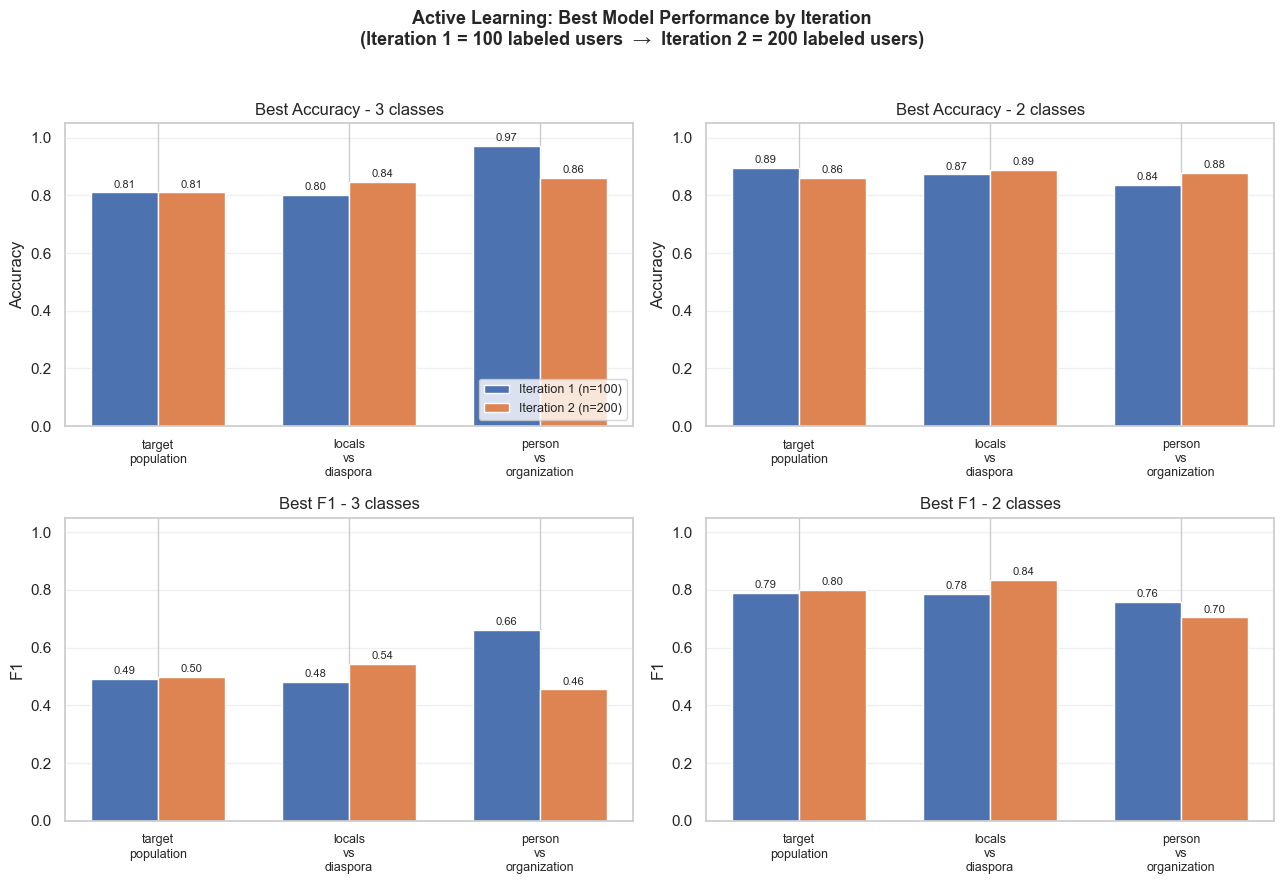

In [30]:
# Step 6.5 - Accuracy / F1 vs Iteration comparison (active learning effect)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

iter1_path = "Classification/iteration_1/experiments_results_iteration_1.csv"
iter2_path = "Classification/iteration_2/experiments_results_iteration_2.csv"
out_png = "Classification/iteration_2/iteration_comparison.png"

e1 = pd.read_csv(iter1_path)
e2 = pd.read_csv(iter2_path)
df_exp = pd.concat([e1, e2], ignore_index=True)

target_columns = ["target_population", "locals_vs_diaspora", "person_vs_organization"]
mode_label = {3: "3 classes", 2: "2 classes"}

# For each (iteration, target, #classes) keep the BEST model by F1.
idx = df_exp.groupby(["iteration", "target_column", "#classes"])["F1"].idxmax()
best = df_exp.loc[idx].copy()

# Build a tidy summary table
summary = best[["iteration", "target_column", "#classes", "algorithm", "training_type",
                "feature_set", "balanced", "accuracy", "F1"]].sort_values(
    ["target_column", "#classes", "iteration"]).reset_index(drop=True)
print("Best model per (target, #classes, iteration):\n")
print(summary.to_string(index=False))

# ------------------------------------------------------------
# Plot: rows = metric (Accuracy, F1), cols = class mode (3, 2)
# x-axis = target, grouped bars per iteration
# ------------------------------------------------------------
metrics = ["accuracy", "F1"]
modes = [3, 2]
iterations = sorted(best["iteration"].unique())
colors = {1: "#4C72B0", 2: "#DD8452"}
x = np.arange(len(target_columns))
width = 0.35

fig, axes = plt.subplots(len(metrics), len(modes), figsize=(13, 9))

for r, metric in enumerate(metrics):
    for c, mode in enumerate(modes):
        ax = axes[r][c]
        for k, it in enumerate(iterations):
            vals = []
            for tgt in target_columns:
                sel = best[(best["iteration"] == it) & (best["target_column"] == tgt) &
                           (best["#classes"] == mode)]
                vals.append(sel[metric].values[0] if len(sel) else np.nan)
            offset = (k - (len(iterations) - 1) / 2) * width
            bars = ax.bar(x + offset, vals, width,
                          label=f"Iteration {it} (n={'100' if it == 1 else '200'})",
                          color=colors.get(it, None))
            for b, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}",
                            ha="center", va="bottom", fontsize=8)
        ax.set_title(f"Best {metric.upper() if metric=='F1' else metric.capitalize()} - {mode_label[mode]}")
        ax.set_xticks(x)
        ax.set_xticklabels([t.replace("_", "\n") for t in target_columns], fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(metric.upper() if metric == "F1" else metric.capitalize())
        ax.grid(axis="y", alpha=0.3)
        if r == 0 and c == 0:
            ax.legend(loc="lower right", fontsize=9)

fig.suptitle("Active Learning: Best Model Performance by Iteration\n"
             "(Iteration 1 = 100 labeled users  →  Iteration 2 = 200 labeled users)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(out_png, bbox_inches="tight", dpi=120)
print(f"\nSaved comparison figure: {out_png}")

### Step 6.6 - Conclusions: Did Active Learning Help?

In Iteration 2 we doubled the labeled set from **100 to 200 users**, where the 100 new
users were the **most uncertain** examples according to the `target_population` model
(active-learning query strategy). We then re-ran the exact same Step 5 experiment table
and compared the best model per task against Iteration 1.

**Best F1 (macro), Iteration 1 -> Iteration 2**

| Task | 3 classes | 2 classes |
|------|-----------|-----------|
| `target_population` | 0.49 -> 0.50 | 0.79 -> **0.80** |
| `locals_vs_diaspora` | 0.48 -> **0.54** | 0.78 -> **0.84** |
| `person_vs_organization` | 0.66 -> 0.46 | 0.76 -> 0.70 |

**Interpretation**

- **The task that drove the query strategy improved/held.** `target_population` stayed stable
  and `locals_vs_diaspora` (strongly correlated with it) improved clearly in both class modes.
  Adding the most informative examples for the target task paid off where it matters most.
- **`person_vs_organization` degraded.** This is *not* a modelling error - it is a direct
  consequence of the query strategy. Because the new users were selected by `target_population`
  uncertainty (not by person/organization uncertainty), they turned out to be **93% persons**,
  pushing the combined class balance to a very skewed **174 / 23 / 3**. A more imbalanced set
  lowers the macro-averaged F1 even when raw accuracy stays high, so this side task suffered.
- **Takeaway.** Active learning optimises the task it queries on. To also improve
  `person_vs_organization`, a future iteration should query using that task's own uncertainty
  (or a multi-task / round-robin strategy) so the newly labelled users are informative for it too.

This completes the active-learning loop for Iteration 2.